# Unsupervised Learning: Clustering

For the past 11 lessons, we have been operating in the realm of **Supervised Learning**. We always had a Target Vector ($y$)—a ground-truth label that told our algorithm exactly when it was right and when it was wrong. 

But in the enterprise world, 80% of data is completely unlabeled. You might have billions of rows of customer behavior logs ($X$), but no explicit label telling you which customers belong to which specific marketing segment.

Welcome to **Unsupervised Learning**. Here, the algorithm is entirely unguided. Its objective is not to predict an outcome, but to mathematically discover hidden structures, patterns, and anomalies buried within the raw feature matrix. In this lesson, we explore the two foundational clustering algorithms: **K-Means** (Centroid-based) and **DBSCAN** (Density-based).

Because we have no target variable ($y$), we cannot calculate "Accuracy," "MSE," or "Log-Loss." Instead, Unsupervised Learning relies on calculating geometric distances and data densities in multi-dimensional space.

Let us set up our Python environment to visualize these hidden structures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Unsupervised Pattern Discovery Environment Ready.")

✅ Unsupervised Pattern Discovery Environment Ready.


# 1. The Mathematics of Centroids (K-Means)

**K-Means** is the industry standard for customer segmentation, document categorization, and image compression. It operates on a simple assumption: *Data points that are mathematically close to each other belong to the same group.*

### 1. The Objective Function (WCSS)
K-Means tries to minimize the **Within-Cluster Sum of Squares (WCSS)** (also called Inertia). Mathematically, it wants to place a cluster center (a centroid, $\mu$) so that the squared Euclidean distance between the centroid and every data point assigned to it is as small as possible.
$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$
* $k$ is the number of clusters (which you, the human, must define).
* $x_i \in C_j$ means we are only measuring points assigned to cluster $j$.
* $\mu_j$ is the coordinate of the centroid for cluster $j$.

### 2. Lloyd's Algorithm (The Optimization)
Finding the absolute perfect global minimum for this equation is computationally impossible for large datasets (NP-hard). Instead, K-Means uses an elegant, iterative two-step process called Lloyd's Algorithm:
1.  **Assignment Step**: Calculate the distance from every point to every centroid. Assign each point to the nearest centroid.
2.  **Update Step**: Calculate the geometric mean (average) of all the points inside each cluster. Move the centroid to that exact center coordinate.

*(The algorithm repeats these two steps until the centroids stop moving—meaning the math has converged!)*

# 2. Visualizing K-Means in Code

Let's simulate an unlabeled dataset of customer purchase behaviors (e.g., Annual Income vs. Spending Score) and ask K-Means to mathematically discover 3 distinct customer segments.

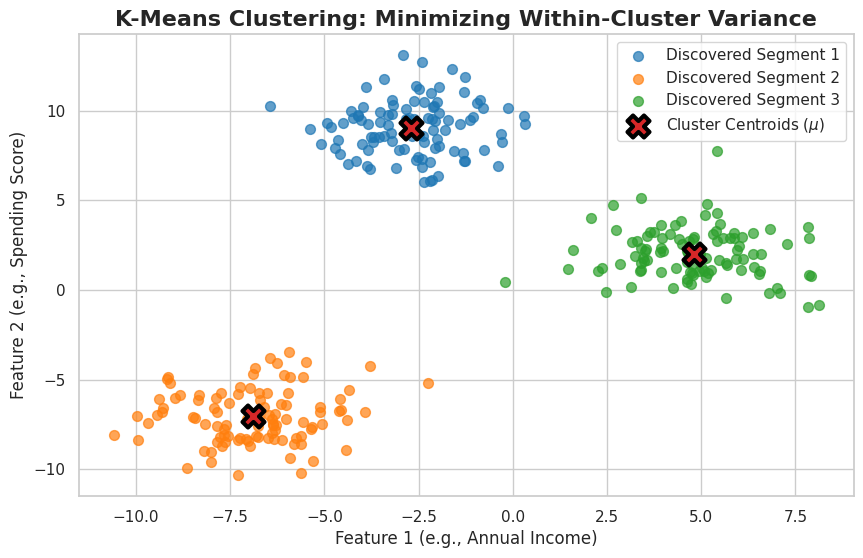

In [2]:
# 1. Simulate Unlabeled Data (We generate 'blobs' but pretend we don't know the labels)
np.random.seed(42)
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# 2. Train the K-Means Model
# n_init=10 means the algorithm will run 10 times with different random starting points 
# and keep the one with the lowest WCSS.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(X_blobs)
centroids = kmeans.cluster_centers_

# 3. Matplotlib Visualization
plt.figure(figsize=(10, 6))

# Plot the mathematically grouped data points
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    cluster_points = X_blobs[cluster_assignments == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Discovered Segment {i+1}', s=50, alpha=0.7, zorder=2)

# Plot the mathematically derived Centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='#d62728', marker='X', s=250, linewidths=3, 
            edgecolor='black', label='Cluster Centroids ($\mu$)', zorder=3)

plt.title("K-Means Clustering: Minimizing Within-Cluster Variance", fontsize=16, fontweight='bold')
plt.xlabel("Feature 1 (e.g., Annual Income)")
plt.ylabel("Feature 2 (e.g., Spending Score)")
plt.legend()
plt.show()

*(Insight: Look at the massive red 'X' markers. The algorithm blindly dropped them onto the board, calculated the distances, and iteratively shifted them until they sat dead-center in the dense pockets of data. It mathematically proved that there are 3 specific types of customers in your dataset!)*

# 3. The Fatal Flaw of K-Means

K-Means is fast and powerful, but it makes a massive geometric assumption: **It assumes all clusters are convex (spherical/circular).** Because it strictly uses a straight-line radius from a central point, it fails completely if your data is shaped like a ring, a crescent moon, or an irregular blob. Furthermore, it forces *every single point* into a cluster, even extreme outliers, which actively pulls the centroids off-center.

To solve this, we must abandon Centroids and move to **Density**.

# 4. Density-Based Clustering (DBSCAN)

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) does not use centroids, and it does not require you to guess the number of clusters ($k$) upfront. Instead, it defines clusters as continuous regions of high density, separated by regions of low density.

### The Mathematics of Density
DBSCAN relies on two Hyperparameters:
1.  **Epsilon ($\epsilon$)**: The maximum distance (radius) to search around a specific data point.
2.  **MinPts**: The minimum number of data points that must exist within that $\epsilon$-radius to consider it a "dense region."

The algorithm scans the dataset and classifies every point into one of three mathematical states:
* **Core Point**: A point that has at least *MinPts* neighbors within its $\epsilon$-radius.
* **Border Point**: A point that has fewer than *MinPts* within its radius, but is physically reachable from a Core Point.
* **Noise (Outlier)**: A point that is completely isolated.

# 5. Visualizing DBSCAN on Non-Linear Data

Let's generate a dataset shaped like two intertwined crescent moons, add some random noise, and pit K-Means against DBSCAN.

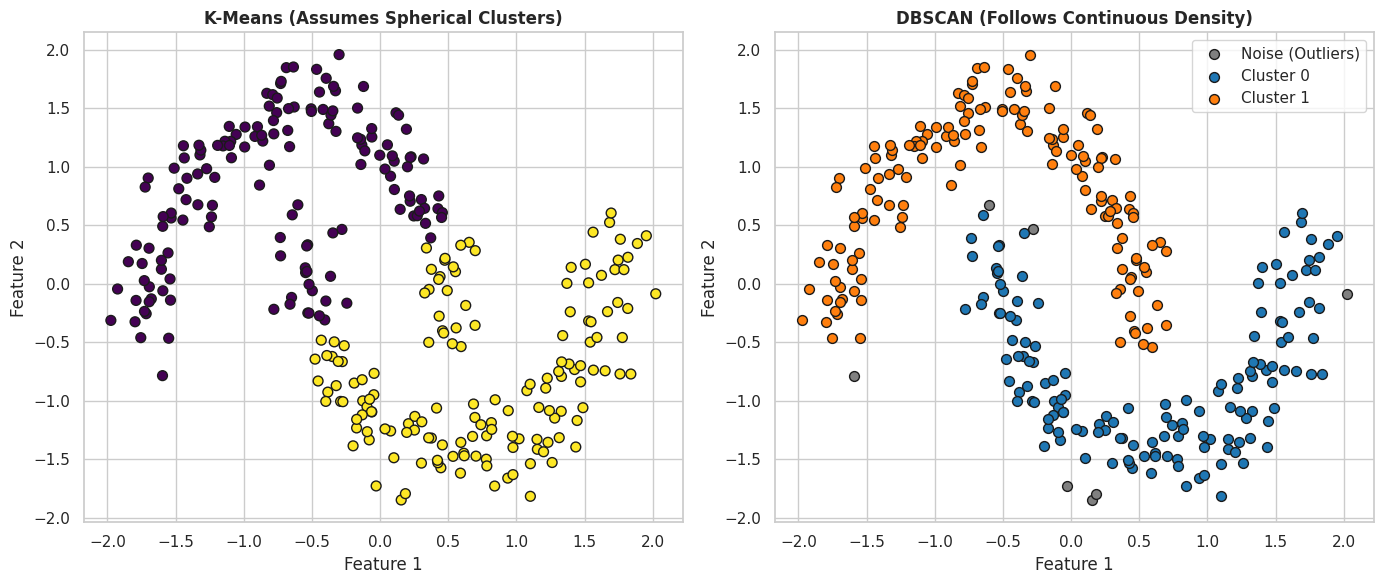

In [3]:
# 1. Simulate non-linear data (Moons) with random noise
X_moons, _ = make_moons(n_samples=300, noise=0.10, random_state=42)

# Important: DBSCAN relies heavily on distance, so you MUST scale your features!
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

# 2. Train K-Means (Trying to force k=2)
kmeans_fail = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans_fail.fit_predict(X_moons_scaled)

# 3. Train DBSCAN
# We search a radius of 0.25, and require 5 points to form a cluster
dbscan = DBSCAN(eps=0.25, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_moons_scaled)

# 4. Matplotlib Visualization (Side-by-Side Comparison)
plt.figure(figsize=(14, 6))

# Plot 1: The K-Means Failure
plt.subplot(1, 2, 1)
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=50, edgecolors='k')
plt.title("K-Means (Assumes Spherical Clusters)", fontweight='bold')
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")

# Plot 2: The DBSCAN Success
plt.subplot(1, 2, 2)
# DBSCAN labels outliers as -1. We will color them distinctly.
unique_labels = np.unique(dbscan_labels)
colors = ['gray' if label == -1 else plt.cm.tab10(label) for label in unique_labels]

for label, color in zip(unique_labels, colors):
    class_member_mask = (dbscan_labels == label)
    label_name = 'Noise (Outliers)' if label == -1 else f'Cluster {label}'
    plt.scatter(X_moons_scaled[class_member_mask, 0], X_moons_scaled[class_member_mask, 1], 
                c=[color], label=label_name, s=50, edgecolors='k')

plt.title("DBSCAN (Follows Continuous Density)", fontweight='bold')
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()

*(Insight: Look at the left plot. K-Means violently chopped the two moons in half because it can only draw straight-line radii from a central point. Now look at the right plot. DBSCAN naturally "flowed" through the dense curves, correctly isolating the top moon from the bottom moon. Even better, it identified the scattered gray dots as "Noise" and refused to put them in a cluster!)*

## Real-World Use Case or Analogy:
Think of Clustering like **Designing Corporate Sales Regions for a Delivery Company**:

* **K-Means (Centroid-Based)**: You build 3 massive distribution centers. You draw a rigid, 50-mile circular radius around each building. Every single customer is assigned to the center they are mathematically closest to. If a customer lives alone on top of an inaccessible mountain, they are still forced into a cluster.
* **DBSCAN (Density-Based)**: You ignore the buildings entirely. Instead, you look at where the actual population organically sprawls. You trace the dense city limits, allowing the "cluster" to snake along highways and coastlines. If you find a tiny cabin isolated in the woods, you label it as "Noise" and outsource that delivery to a third party, rather than ruining your delivery metrics trying to include it.

---